In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

In [2]:
df = pd.read_csv('../data/synthetic_data.csv')
df.head()

,offer_count,isRecurrentUser,antiguedadIngresos,offered_rate,numeroPagos,fico,isFraud,took_loan
0,3,0,7,0.496678,16,541,0,0
1,4,1,3,0.316401,19,511,0,1
2,1,1,14,0.493938,1,820,1,0
3,3,1,10,0.475599,5,733,1,1
4,3,1,16,0.281125,22,828,0,1


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   offer_count         2000 non-null   int64  
 1   isRecurrentUser     2000 non-null   int64  
 2   antiguedadIngresos  2000 non-null   int64  
 3   offered_rate        2000 non-null   float64
 4   numeroPagos         2000 non-null   int64  
 5   fico                2000 non-null   int64  
 6   isFraud             2000 non-null   int64  
 7   took_loan           2000 non-null   int64  
dtypes: float64(1), int64(7)
memory usage: 125.1 KB


,offer_count,isRecurrentUser,antiguedadIngresos,offered_rate,numeroPagos,fico,isFraud,took_loan
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,2.474000,0.511500,10.150500,0.295654,18.056500,674.565000,0.516000,0.500000
std,1.125148,0.499993,5.493263,0.115785,9.969002,102.291444,0.499869,0.500125
min,1.000000,0.000000,1.000000,0.100075,1.000000,500.000000,0.000000,0.000000
25%,1.000000,0.000000,5.000000,0.195961,10.000000,585.000000,0.000000,0.000000
50%,2.000000,1.000000,10.000000,0.294067,18.000000,675.500000,1.000000,0.500000
75%,3.000000,1.000000,15.000000,0.397433,26.250000,761.000000,1.000000,1.000000
max,4.000000,1.000000,19.000000,0.499620,35.000000,849.000000,1.000000,1.000000


In [4]:
X = df.drop(columns='took_loan')
y = df['took_loan']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [5]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [6]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.74      0.78      0.76       200
           1       0.77      0.72      0.75       200

    accuracy                           0.75       400
   macro avg       0.75      0.75      0.75       400
weighted avg       0.75      0.75      0.75       400

ROC-AUC: 0.8391500000000001


In [7]:
coefficients = model.coef_[0]
features = X.columns

odds_ratios = pd.Series(np.exp(coefficients), index=features).sort_values()
odds_ratios

offered_rate          0.171491
numeroPagos           0.976693
antiguedadIngresos    0.996932
fico                  0.999169
isFraud               1.021457
offer_count           2.752974
isRecurrentUser       5.299660
dtype: float64

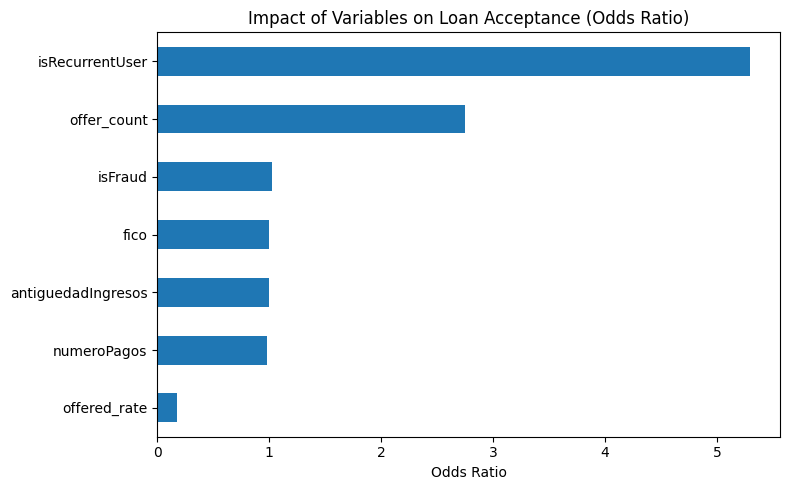

In [8]:
plt.figure(figsize=(8,5))
odds_ratios.plot(kind='barh')
plt.title("Impact of Variables on Loan Acceptance (Odds Ratio)")
plt.xlabel("Odds Ratio")
plt.tight_layout()
plt.savefig('../outputs/figures/odds_ratio.png')
plt.show()

In [9]:
df['probability'] = model.predict_proba(X)[:, 1]
df[['probability']].head()

,probability
0,0.371495
1,0.919743
2,0.319281
3,0.784296
4,0.752921


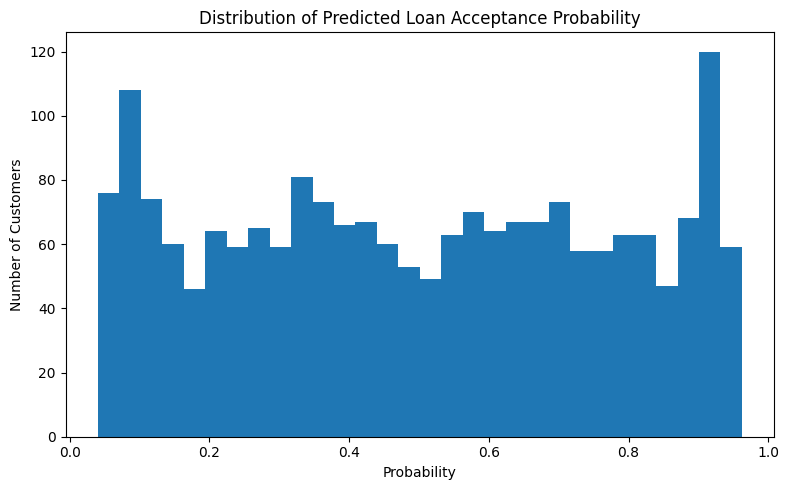

In [10]:
plt.figure(figsize=(8,5))
plt.hist(df['probability'], bins=30)
plt.title("Distribution of Predicted Loan Acceptance Probability")
plt.xlabel("Probability")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.savefig('../outputs/figures/probability_distribution.png')
plt.show()

In [11]:
df['segment'] = pd.cut(
    df['probability'],
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1],
    labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'],
    include_lowest=True
)

segment_counts = df['segment'].value_counts().sort_index()
segment_counts

segment
Very Low     377
Low          439
Medium       387
High         425
Very High    372
Name: count, dtype: int64

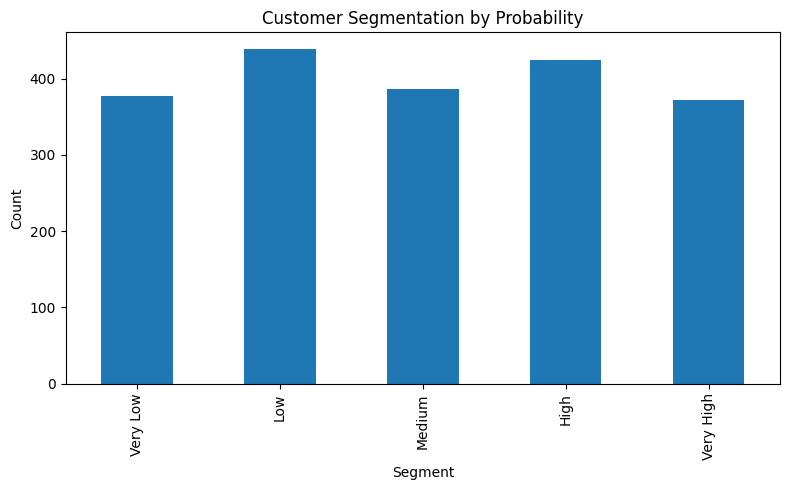

In [12]:
plt.figure(figsize=(8,5))
segment_counts.plot(kind='bar')
plt.title("Customer Segmentation by Probability")
plt.xlabel("Segment")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig('../outputs/figures/segmentation.png')
plt.show()

In [13]:
df.to_csv('../data/synthetic_scored_data.csv', index=False)